# α-Helix Secondary Structure — End-to-End Pipeline
### Two-state HMM → Forward–Backward → BayesFlow → real-protein evaluation

This notebook runs **every step of the project in order, with diagrams**. It reuses the
project modules (`simulate.py`, `forward_backward.py`, `train_bayesflow.py`,
`insulin_eval.py`) so the model is defined in exactly **one** place.

**How to run:** open this notebook from the `restart/` folder and choose
*Kernel → Restart & Run All*. Heavy steps use a small demo scale for interactivity;
the full-scale results are shown from the saved runs.

| Step | What happens |
|------|--------------|
| 0 | The statistical model — a two-state HMM |
| 1 | Simulator — generate chains matched to real lengths |
| 2 | Forward–Backward — exact per-residue P(helix) targets |
| 3 | BayesFlow — amortized neural posterior (windowing + encoding) |
| 4 | Insulin & real-protein evaluation |
| 5 | Comparison & results |

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "torch")   # must precede keras/bayesflow import
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from sklearn.metrics import roc_auc_score

TEAL, DEEP = "#1D9E75", "#0F6E56"
rng = np.random.default_rng(0)
print("environment ready — cwd:", os.getcwd())

environment ready — cwd: D:\SBI\restart


## Step 0 — The statistical model: a two-state HMM

Two hidden states, **helix** and **other**. Every chain starts in *other*. The state path is a
first-order Markov chain; each state emits an amino acid from its own table. All numbers come
from `simulate.py` (single source of truth).

In [2]:
from simulate import AA, START_PROB, TRANS, EMIT, H, O, N_AA

print("Amino-acid alphabet:", "".join(AA))
print("\nStart distribution [helix, other]:", START_PROB, " -> always starts in 'other'")
print("\nTransition matrix (row = current state):")
print("             ->helix  ->other")
for name, i in [("helix", H), ("other", O)]:
    print(f"  from {name:5s}   {TRANS[i,H]:.2f}     {TRANS[i,O]:.2f}")
print("\nEmission probabilities (%):")
print("  AA    " + " ".join(f"{a:>3}" for a in AA))
for name, row in zip(["helix", "other"], EMIT):
    print(f"  {name:5s} " + " ".join(f"{int(round(v*100)):>3}" for v in row))

Amino-acid alphabet: ARNDCEQGHILKMFPSTWYV

Start distribution [helix, other]: [0. 1.]  -> always starts in 'other'

Transition matrix (row = current state):
             ->helix  ->other
  from helix   0.90     0.10
  from other   0.05     0.95

Emission probabilities (%):
  AA      A   R   N   D   C   E   Q   G   H   I   L   K   M   F   P   S   T   W   Y   V
  helix  12   6   3   5   1   9   5   4   2   7  12   6   3   4   2   5   4   1   3   6
  other   6   5   5   6   2   5   3   9   3   5   8   6   2   4   6   7   6   1   4   7


**Diagram — the two-state HMM and its emission tables:**

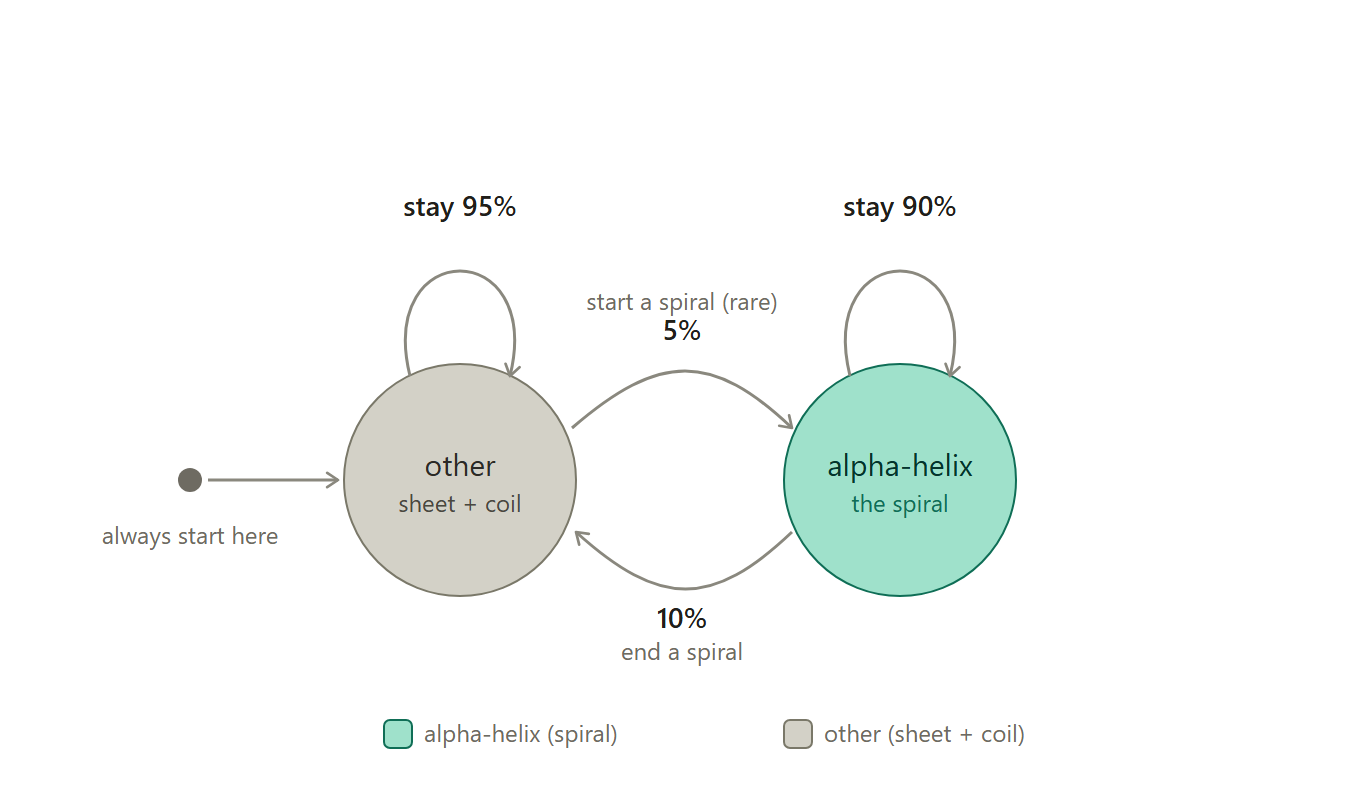

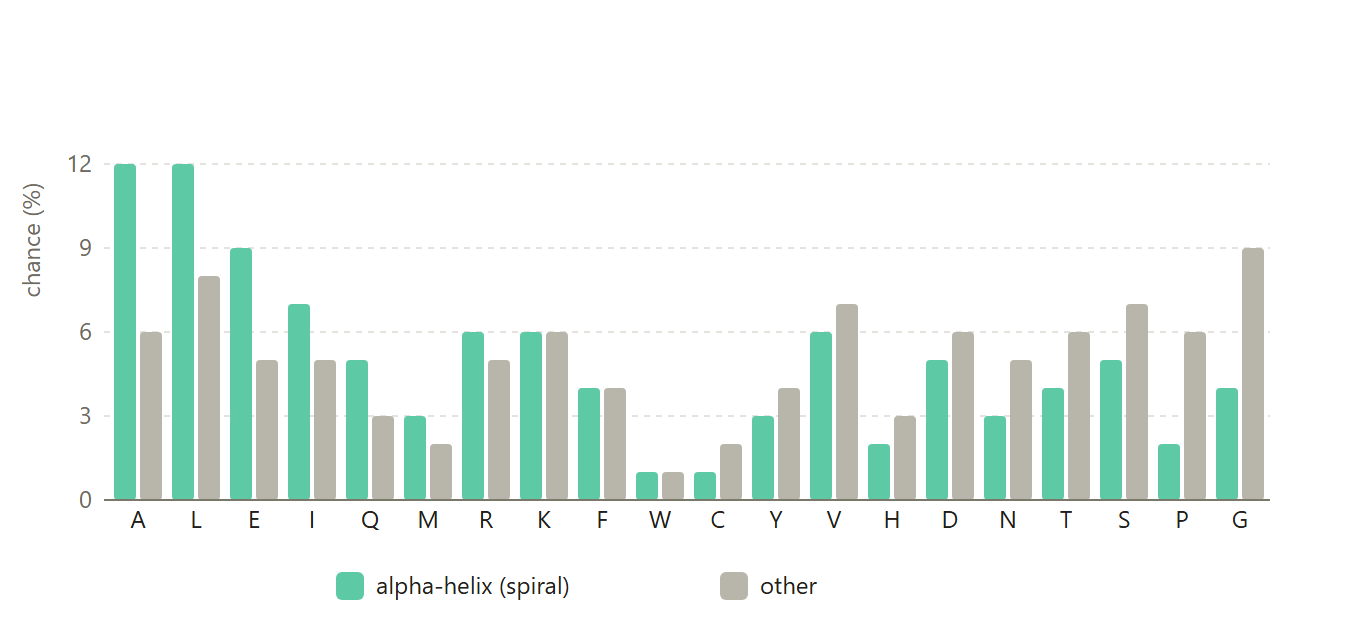

In [3]:
display(Image(filename="../hmm_explainer/1_two_state_hmm.png"))
display(Image(filename="../hmm_explainer/2_emission_probabilities.png"))

## Step 1 — Simulator

Generate amino-acid chains from the HMM. Chain **lengths are sampled from the real PISCES
length distribution**, so the synthetic set mirrors real proteins in length.

In [4]:
from simulate import simulate_chain, load_lengths

# one example chain
st, seq, n_h = simulate_chain(60, rng)
print("hidden states:", st)
print("amino acids  :", seq)

# a demo set (small, for interactivity; the real run uses 100,000)
gt_lengths = load_lengths("../archive/2018-06-06-pdb-intersect-pisces.csv")
N_DEMO = 4000
lengths = rng.choice(gt_lengths, size=N_DEMO, replace=True)
chains = [simulate_chain(int(L), rng) for L in lengths]
hf = sum(c[2] for c in chains) / sum(len(c[0]) for c in chains)
print(f"\nsimulated {N_DEMO} chains; helix fraction {hf:.3f} (stationary theory 0.333)")

hidden states: OOHHHOOOOOOHHHHHHHHHHHHHHHOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO
amino acids  : GDALEFDVGRKYGVIGLVVHFIIFGMPVNPYVATVVNVWTICSYELIVAPKAPASLYRTR



simulated 4000 chains; helix fraction 0.322 (stationary theory 0.333)


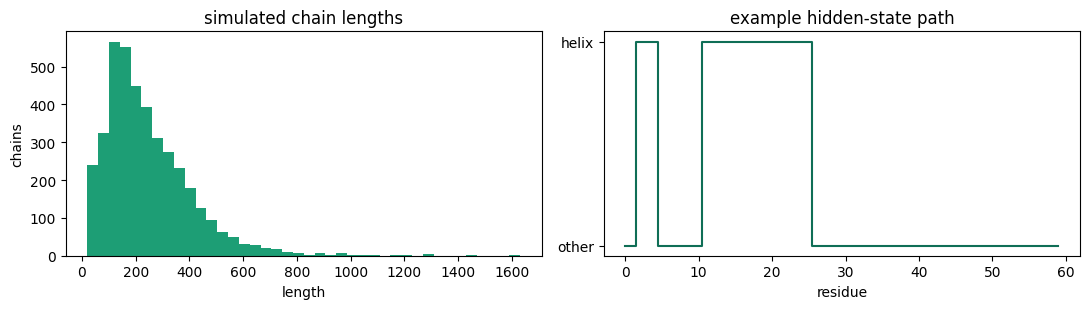

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(lengths, bins=40, color=TEAL)
ax[0].set(title="simulated chain lengths", xlabel="length", ylabel="chains")
s0 = np.array([1 if c == 'H' else 0 for c in st])
ax[1].step(range(len(s0)), s0, where="mid", color=DEEP)
ax[1].set(title="example hidden-state path", xlabel="residue", yticks=[0, 1])
ax[1].set_yticklabels(["other", "helix"])
plt.tight_layout(); plt.show()

## Step 2 — Forward–Backward (exact per-residue posterior)

Given a sequence, `hmmlearn`'s Forward–Backward gives the exact **P(helix | whole chain)** for
every residue. These are the "answer key" targets that BayesFlow will learn to reproduce.

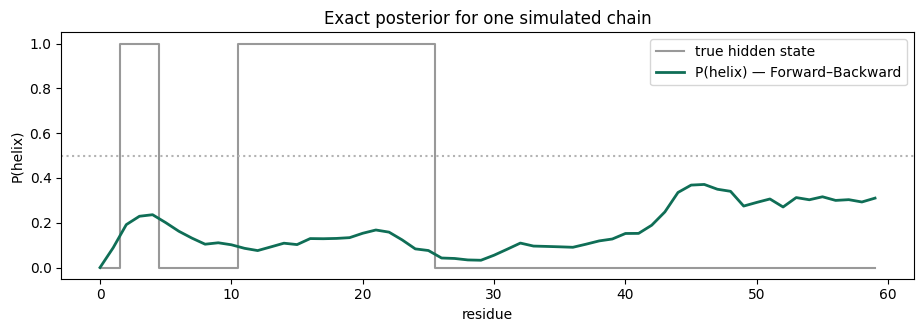

residue-0 P(helix) = 0.0  (start rule -> exactly 0)


In [6]:
from forward_backward import build_model, fb_posterior, encode

fb_model = build_model()
p_helix, loglik = fb_posterior(seq, fb_model)
true = np.array([1 if c == 'H' else 0 for c in st])

plt.figure(figsize=(11, 3.2))
plt.step(range(len(true)), true, where="mid", color="0.6", label="true hidden state")
plt.plot(p_helix, color=DEEP, lw=2, label="P(helix) — Forward–Backward")
plt.axhline(0.5, ls=":", color="0.7"); plt.ylim(-.05, 1.05)
plt.xlabel("residue"); plt.ylabel("P(helix)"); plt.legend()
plt.title("Exact posterior for one simulated chain"); plt.show()
print("residue-0 P(helix) =", round(float(p_helix[0]), 3), " (start rule -> exactly 0)")

In [7]:
# validate the exact posterior against the KNOWN hidden states over a subset
pa, ta = [], []
for st_i, seq_i, _ in chains[:1000]:
    p, _ = fb_posterior(seq_i, fb_model); pa.append(p)
    ta.append((np.frombuffer(st_i.encode(), np.uint8) == ord('H')).astype(int))
pa = np.concatenate(pa); ta = np.concatenate(ta)
print(f"mean P(helix) {pa.mean():.3f}  vs  true helix fraction {ta.mean():.3f}  (well calibrated)")
print(f"AUC vs true hidden state {roc_auc_score(ta, pa):.3f}  (Bayes-optimal ceiling ~0.79)")

mean P(helix) 0.323  vs  true helix fraction 0.322  (well calibrated)
AUC vs true hidden state 0.792  (Bayes-optimal ceiling ~0.79)


## Step 3 — BayesFlow amortized posterior

A normalizing flow needs a **fixed-size** input, but chains vary in length. So we predict **one
residue at a time** from a fixed **31-residue window** (±15), slid along the chain. The window is
**one-hot encoded** as 31 × 21 channels (20 amino acids + 1 padding for chain ends). Because the
window is only local, the target stays uncertain → a genuine posterior (mean ± std).

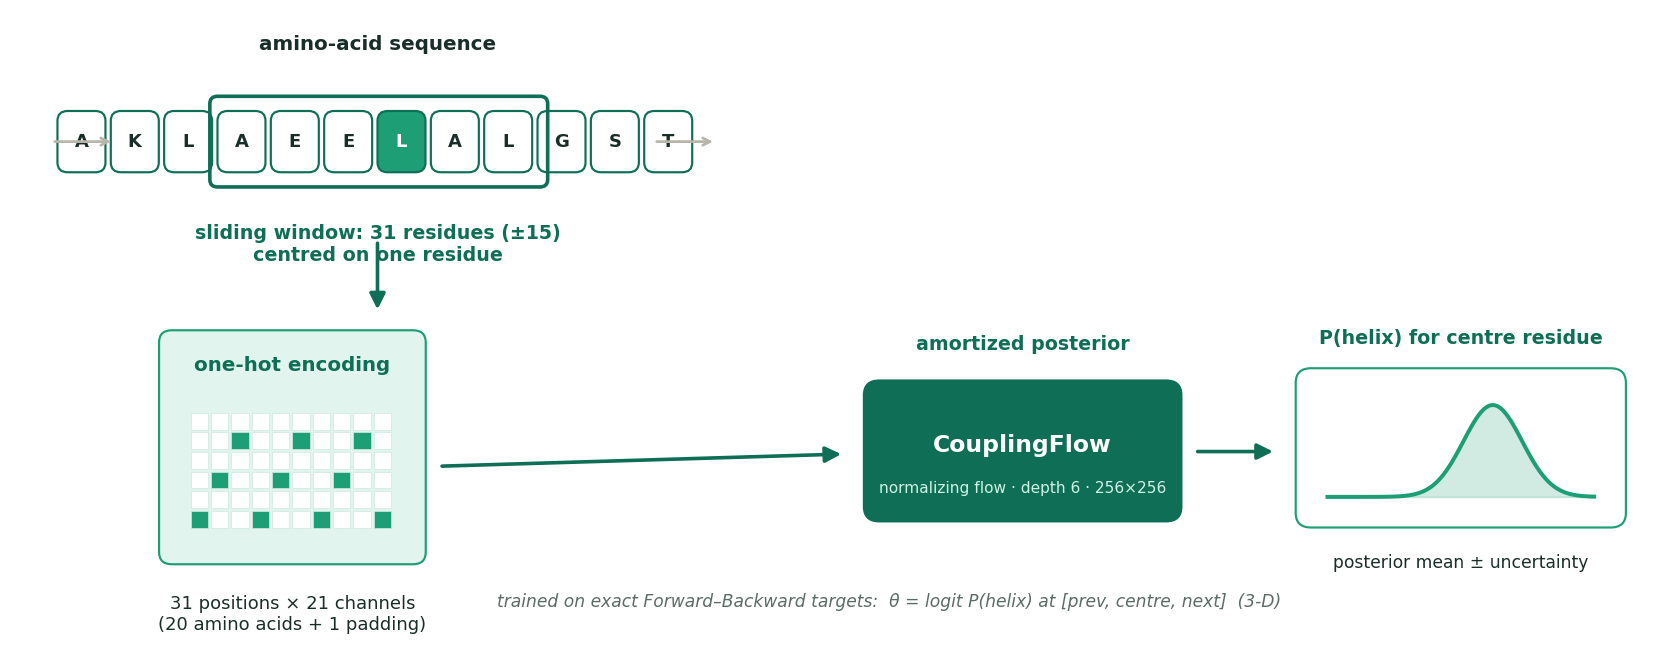

one window per residue -> shape (L, WINDOW, channels) = (60, 31, 21)
WINDOW = 31 residues,  channels = 21 (20 amino acids + 1 padding)


In [8]:
display(Image(filename="bayesflow_window_schematic.png"))

from train_bayesflow import windows_for_sequence, WINDOW, N_CH, predict_helix
Wex = windows_for_sequence(encode(seq))
print(f"one window per residue -> shape (L, WINDOW, channels) = {Wex.shape}")
print(f"WINDOW = {WINDOW} residues,  channels = {N_CH} (20 amino acids + 1 padding)")

Load the trained posterior and compare it to exact FB on the example chain.
*(To retrain from scratch: `python train_bayesflow.py` — 15,000 chains, 300,000 windows, 30 epochs.)*

INFO:bayesflow:Using backend 'torch'


When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


C:\Users\MUNISH\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  2.21batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  2.21batch/s]

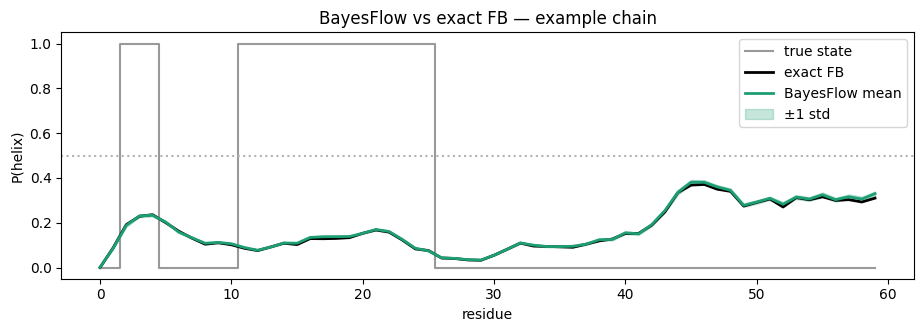

In [9]:
import bayesflow as bf     # registers serializable classes for loading
import keras
approx = keras.saving.load_model("bayesflow_posterior.keras")

mean, std = predict_helix(approx, encode(seq), num_samples=200)

plt.figure(figsize=(11, 3.2))
plt.step(range(len(true)), true, where="mid", color="0.6", label="true state")
plt.plot(p_helix, "k-", lw=2, label="exact FB")
plt.plot(mean, color=TEAL, lw=2, label="BayesFlow mean")
plt.fill_between(range(len(mean)), np.clip(mean - std, 0, 1), np.clip(mean + std, 0, 1),
                 color=TEAL, alpha=0.25, label="±1 std")
plt.axhline(0.5, ls=":", color="0.7"); plt.ylim(-.05, 1.05)
plt.xlabel("residue"); plt.ylabel("P(helix)"); plt.legend()
plt.title("BayesFlow vs exact FB — example chain"); plt.show()

**Validation on held-out simulated chains (full 15k-chain run):** correlation 0.999, MAE 0.007.

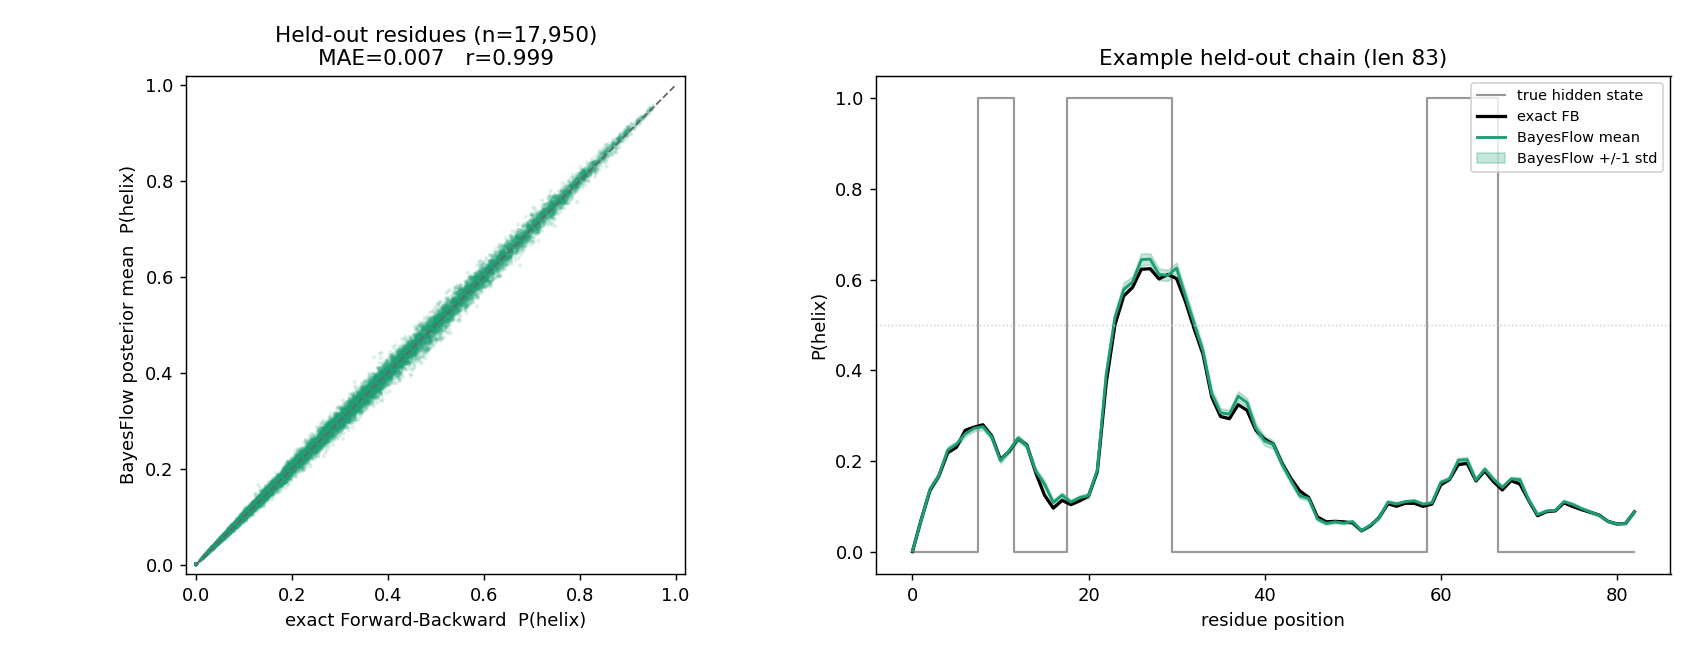

In [10]:
display(Image(filename="validation_figure.png"))

## Step 4 — Insulin & real-protein evaluation

The model trained **only on simulated data**, so real proteins are genuinely held out (no leakage).
We pull human insulin (1A7F) and its true DSSP labels straight from the dataset and score the
posterior against the strict H-only helix labels.

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  4.89batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  4.86batch/s]

insulin chain A (len 21, helix  4): BayesFlow AUC=0.971   FB AUC=0.971


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  3.78batch/s]

Sampling: 100%|██████████| 1/1 [00:00<00:00,  3.76batch/s]

insulin chain B (len 29, helix 10): BayesFlow AUC=0.984   FB AUC=0.984


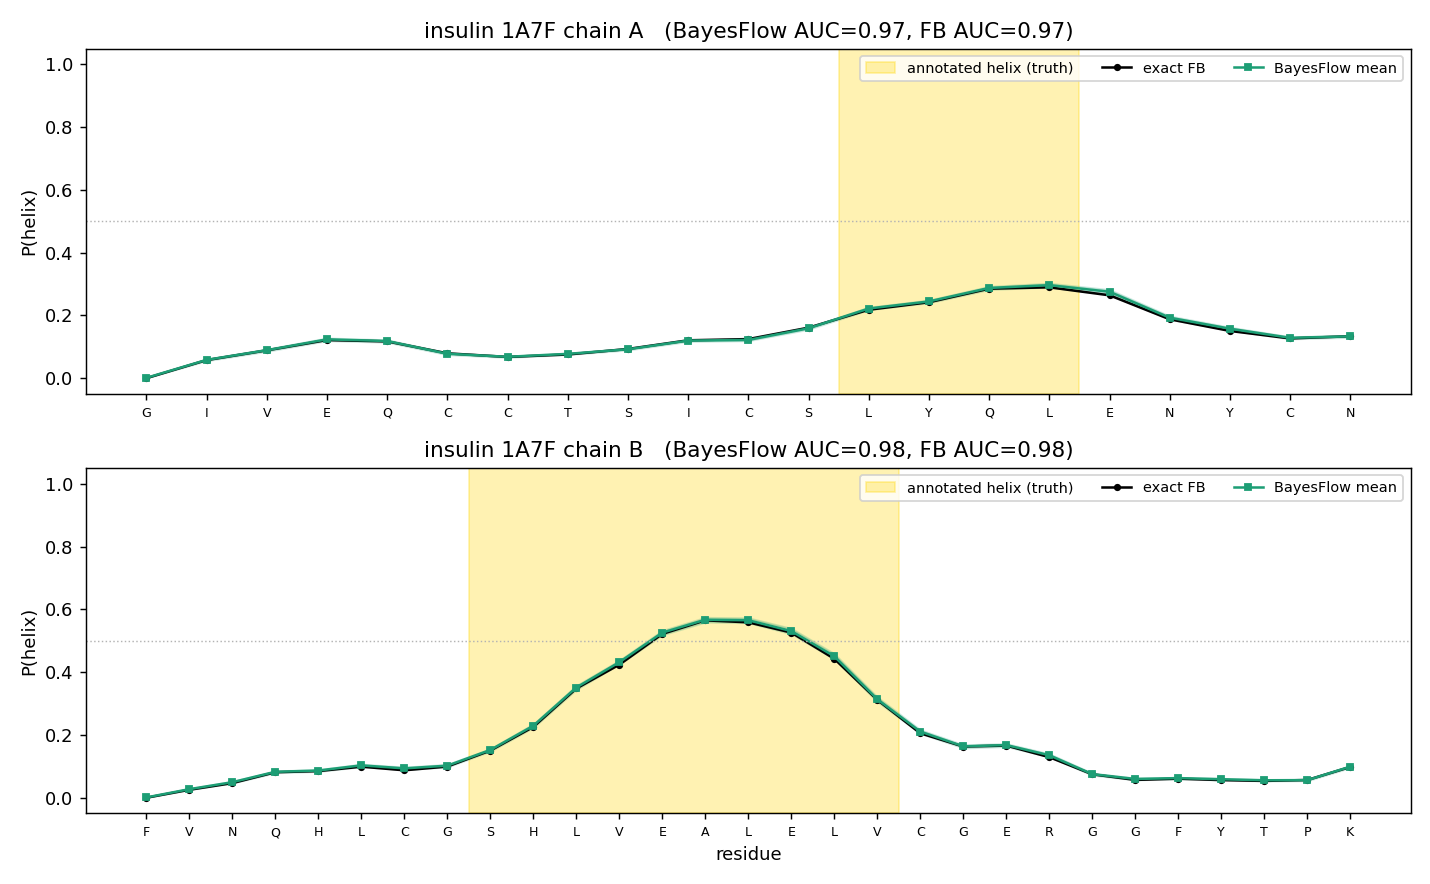

In [11]:
from insulin_eval import fetch_chains

for code_, seqi, sst8 in fetch_chains("1A7F"):
    obs = encode(seqi)
    ti = np.array([1 if c == 'H' else 0 for c in sst8], dtype=int)
    bfp, _ = predict_helix(approx, obs, num_samples=300)
    fbp, _ = fb_posterior(seqi, fb_model)
    print(f"insulin chain {code_} (len {len(seqi):>2}, helix {int(ti.sum()):>2}): "
          f"BayesFlow AUC={roc_auc_score(ti, bfp):.3f}   FB AUC={roc_auc_score(ti, fbp):.3f}")

display(Image(filename="insulin_prediction.png"))

**All real PISCES proteins** (full run: `python eval_real.py --limit 0`) — 8,994 chains, per-chain
AUC 0.754, BayesFlow = exact FB.

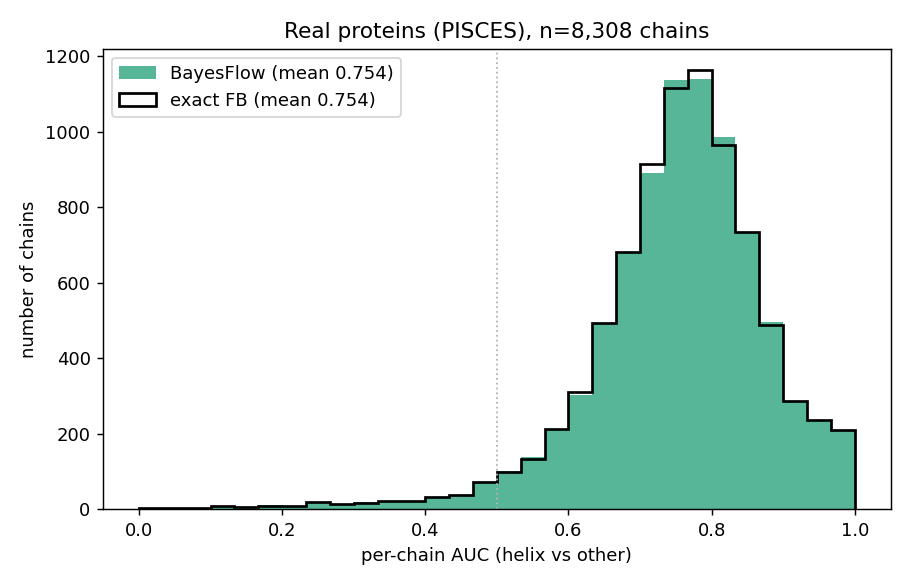

In [12]:
display(Image(filename="real_eval_auc_hist.png"))

## Step 5 — Comparison & results

BayesFlow reproduces exact Forward–Backward in **every** setting, and both track ground truth
equally — high on insulin's textbook helices, ~0.75 across the real proteome.

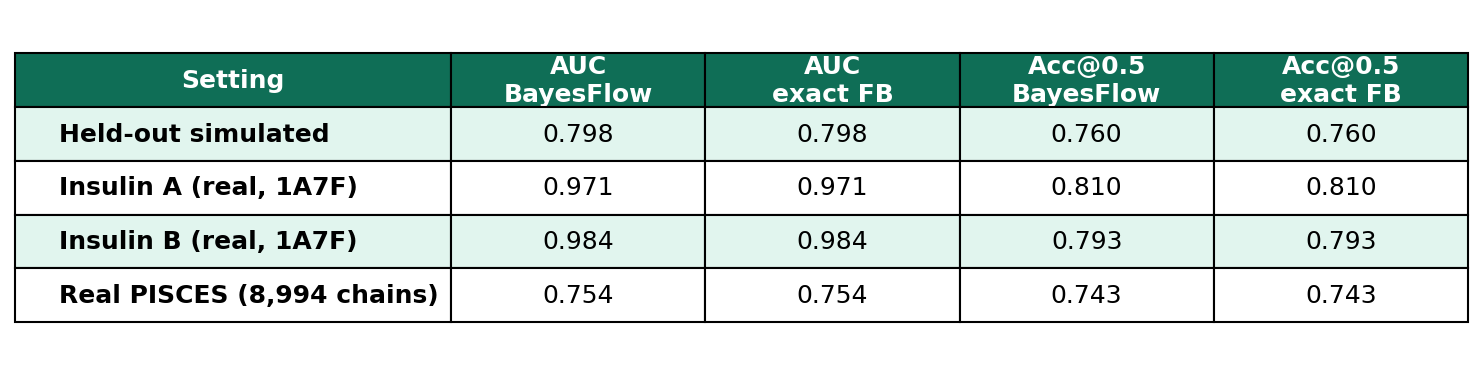

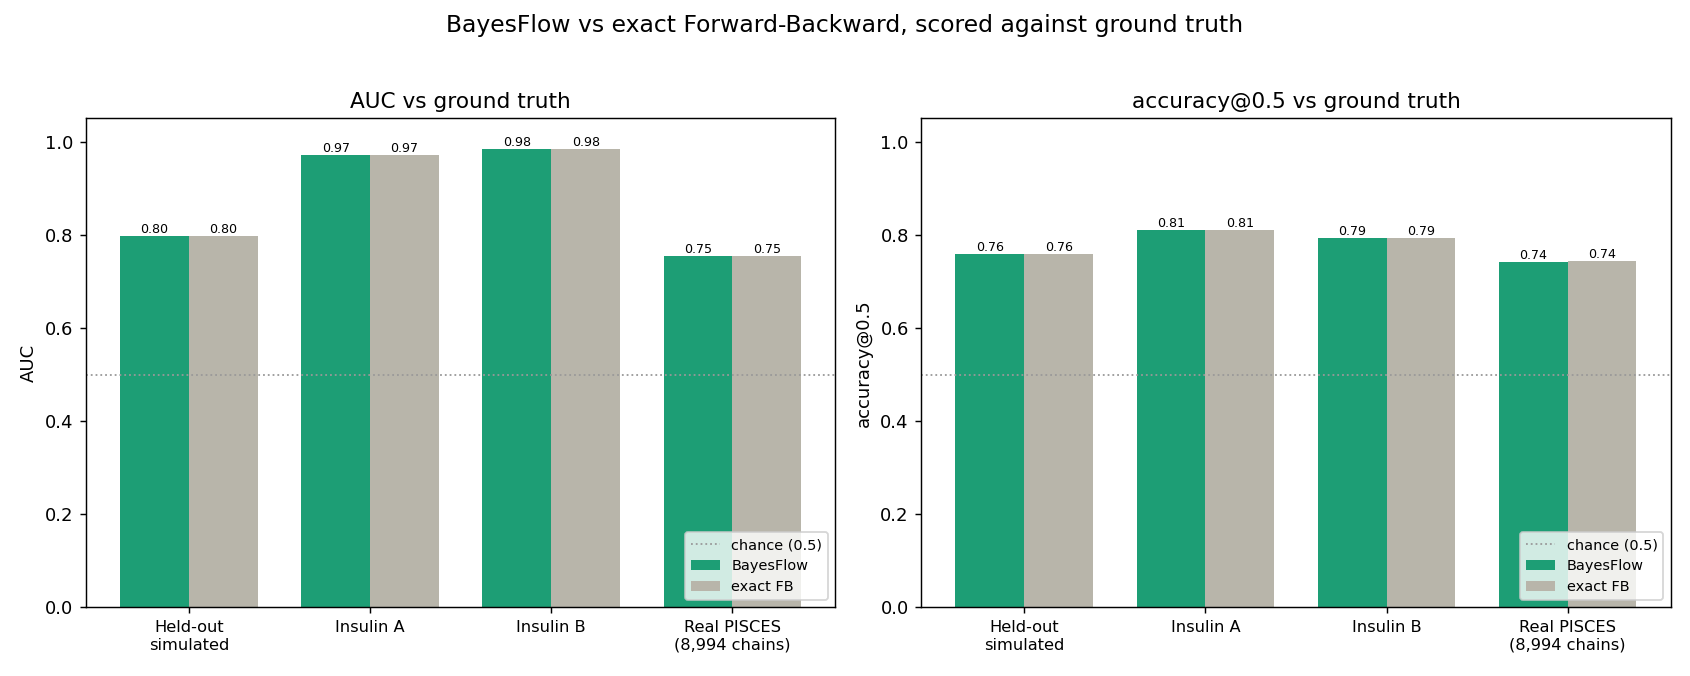

In [13]:
display(Image(filename="comparison_table.png"))
display(Image(filename="comparison.png"))

## TL;DR

- α-helix modeled as a **2-state HMM** whose transition probabilities **match real proteins** (0.912 vs 0.90).
- Trained a **BayesFlow** amortized posterior on exact **Forward–Backward** targets via a sliding **31-residue window**.
- It **reproduces exact FB almost perfectly** (r = 0.999) — instant inference, no HMM at test time.
- On **unseen real proteins** it ranks helices well (insulin AUC 0.97–0.98; PISCES 0.75), bounded by the model's Bayes ceiling.